## Step 1: Import Necessary Libraries

In [69]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

---
## Step 2: Load Dataset

In [33]:
# Load dataset
df = pd.read_csv("CarPrice_Assignment.csv") 

# Display first 5 rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


---
## Step 3: Basic Data Understanding

In [34]:
# Shape of dataset
print("Shape:", df.shape)

Shape: (205, 26)


**Observation:-** data set contains `205 rows` and `26 columns`.

In [35]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

**Observation:-** The dataset is 100% complete with 205 entries and no missing values across its 26 variables. To build the model, we must encode categorical features like fueltype and drop the redundant car_ID column.


In [36]:
# Missing values
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

**Observation:-** There are no missing values present in the dataset.

In [37]:
# Check duplicates
df.duplicated().sum()

0

**Observation:-** There are no Duplicates present in the dataset.

In [38]:
# Statistical Summary
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [39]:
df.describe(include = 'object')

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,toyota corona,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


---
## Step 4: Data Cleaning

In [40]:
# Drop unnecessary columns
df = df.drop(['car_ID', 'CarName'], axis=1)

#### Convert Target Variable (fueltype)

`Gas = 0` &
`Diesel = 1`

In [41]:
df['fueltype'] = df['fueltype'].map({'gas': 0, 'diesel': 1})
df['fueltype'].value_counts()

fueltype
0    185
1     20
Name: count, dtype: int64

**Observation:-** the data set was highly imbalanced.

---
## Step 5: Exploratory Data Analysis (EDA)

### Target Variable Distribution

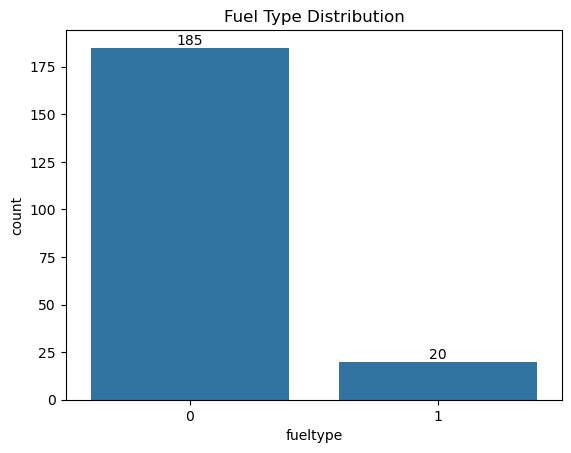

In [42]:
ax = sns.countplot(x='fueltype', data=df)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Fuel Type Distribution")
plt.show()

**Observation:-** The dataset is highly imbalanced, with `gas cars (185)` vastly outnumbering `diesel cars (20)`. This suggests the model may struggle to accurately predict the minority diesel class without specialized techniques.

### Univariate Analysis (Numerical Features)

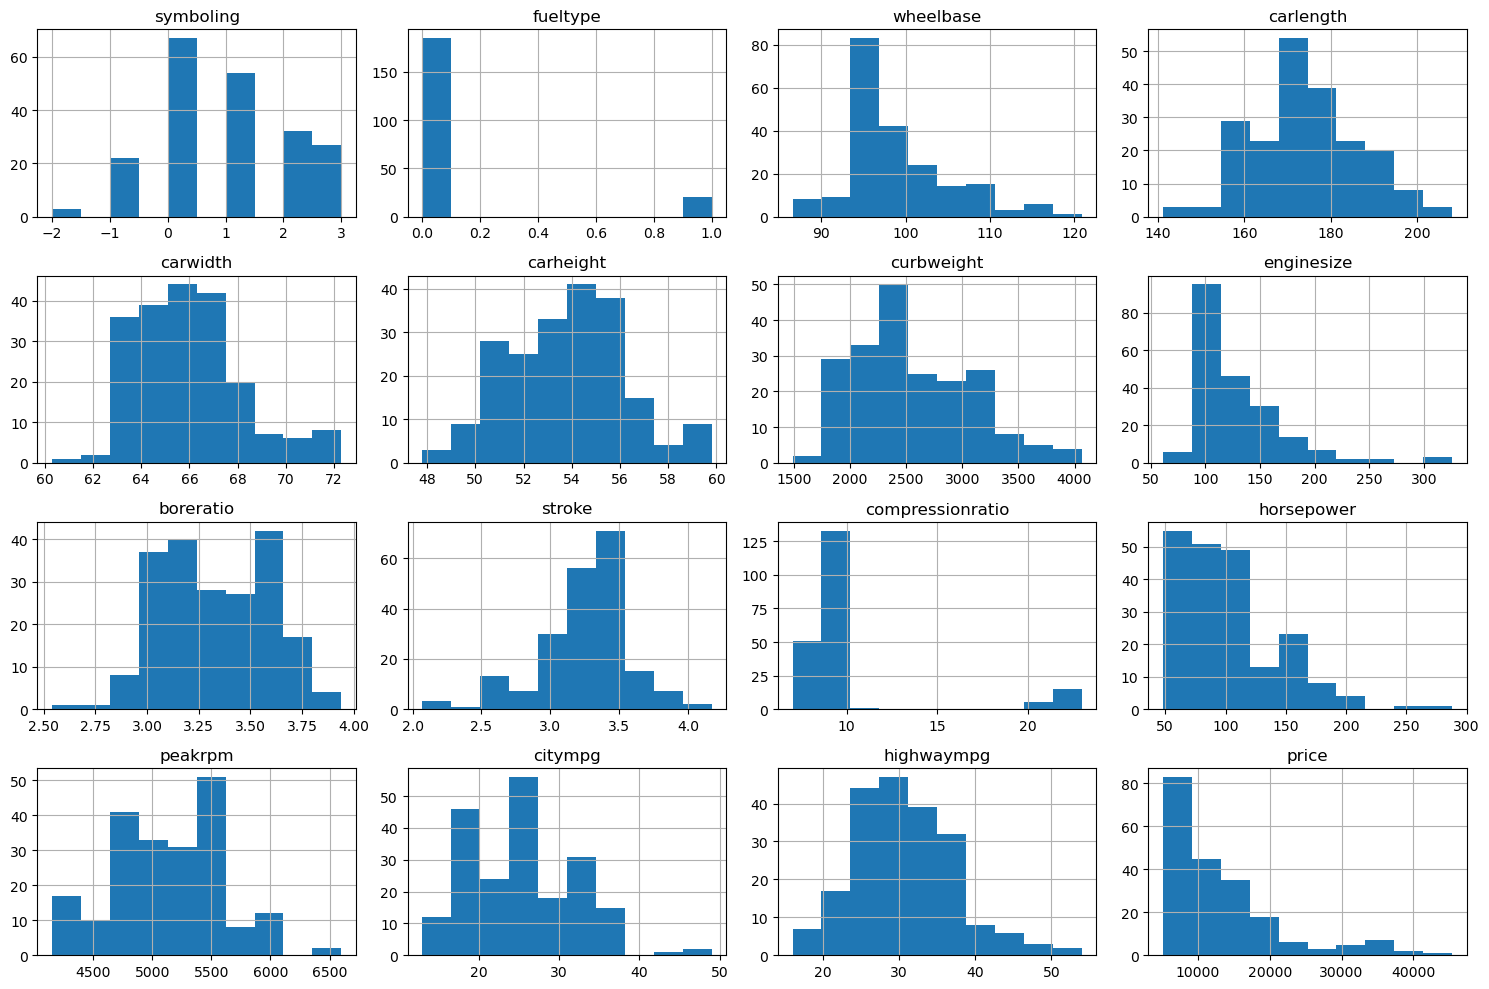

In [43]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

**Observation:-** 
- Severe Class Imbalance: The market is dominated by gas vehicles (185) compared to very few diesel options (20), meaning our model must be careful not to ignore the diesel "minority."

- Skewed Performance Specs: Most cars cluster around lower horsepower and smaller engine sizes, while high-value features like `price` and `compressionratio` show distinct outliers that will likely separate gas from diesel models.

### Bivariate Analysis (Numerical vs Fueltype)

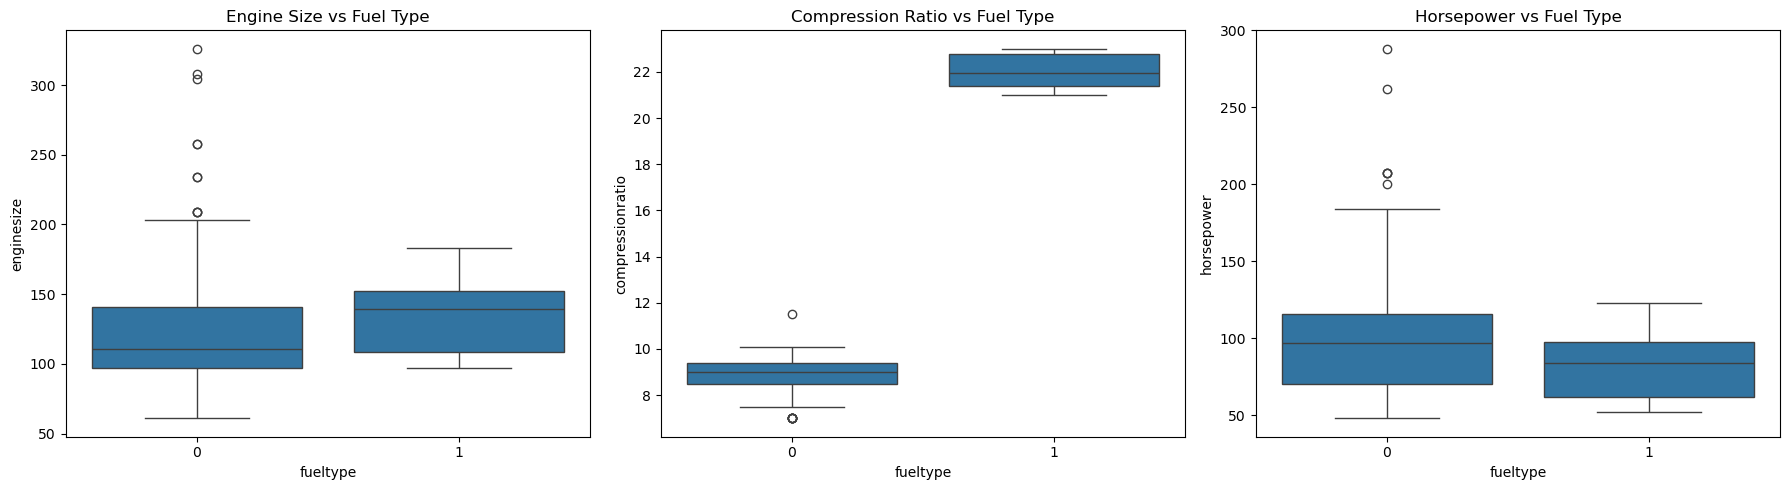

In [44]:
plt.figure(figsize=(18, 5))

# Subplot 1: Engine Size
plt.subplot(1, 3, 1)
sns.boxplot(x='fueltype', y='enginesize', data=df)
plt.title('Engine Size vs Fuel Type')

# Subplot 2: Compression Ratio
plt.subplot(1, 3, 2)
sns.boxplot(x='fueltype', y='compressionratio', data=df)
plt.title('Compression Ratio vs Fuel Type')

# Subplot 3: Horsepower
plt.subplot(1, 3, 3)
sns.boxplot(x='fueltype', y='horsepower', data=df)
plt.title('Horsepower vs Fuel Type')

plt.tight_layout()
plt.show()

**Observation:-** 
- `The Diesel Signature: Compression ratio` is the clearest separator. Diesel cars operate at much higher ratios (20+) compared to gas cars, which stay below 12.

- `Engine & Power`: While diesel engines show a slightly higher and more consistent average `engine size`, they surprisingly produce lower peak `horsepower` than the top-tier gas engines.

- `Consistency`: Diesel vehicles show much less variation in their specs (smaller boxes) compared to gas vehicles, which cover a much wider range of performance levels.

---
## Step 6: Data Preprocessing

### Encode Categorical Variables

In [45]:
df = pd.get_dummies(df, drop_first=True)

### Separate Features & Target

In [46]:
X = df.drop('fueltype', axis=1)
y = df['fueltype']

### Train-Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
X_train.shape

(164, 43)

In [49]:
X_test.shape

(41, 43)

In [50]:
y_train.shape

(164,)

In [51]:
y_test.shape

(41,)

### Apply SMOTE (Only on Training Data)

In [54]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 fueltype
0    148
1     16
Name: count, dtype: int64

After SMOTE:
 fueltype
0    148
1    148
Name: count, dtype: int64


### Feature Scaling

In [55]:
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

---
## Step 7: Model Building (Logistic Regression)

In [56]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

---
## Step 8: Predictions

In [57]:
y_pred = model.predict(X_test)

--- 
## Step 9: Model Evaluation
#### Accuracy

In [58]:
accuracy_score(y_test, y_pred)

1.0

#### Classification Report

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00         4

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



#### Confusion Matrix

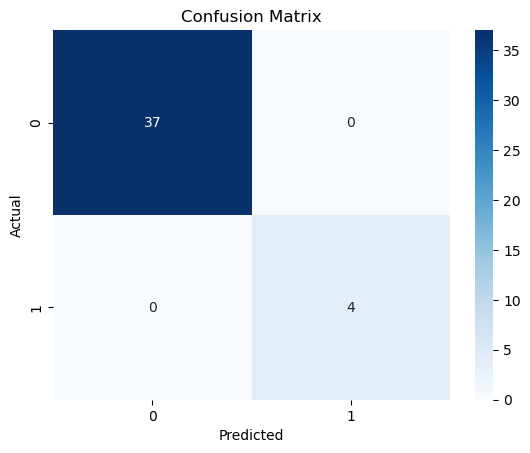

In [59]:
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### ROC-AUC Score

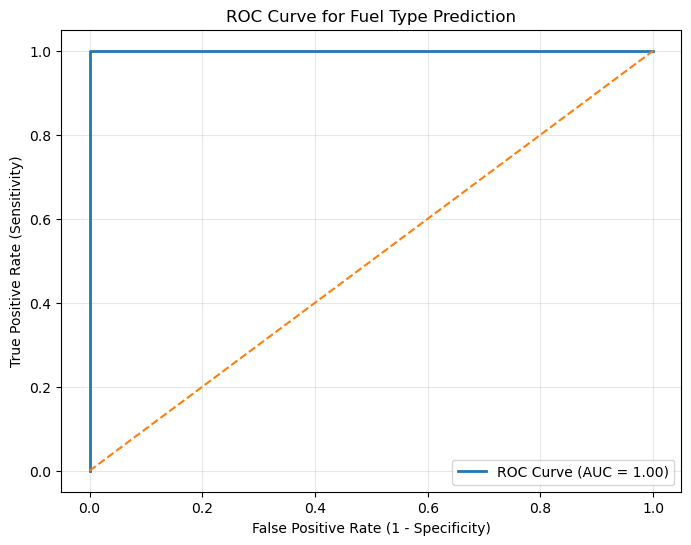

In [71]:
# Get probability scores for class 1 (Diesel)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Random model line

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Fuel Type Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [72]:
# Print AUC Score
print("AUC Score:", roc_auc)

AUC Score: 1.0


---
## Step 10: Identify Important Features

In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
9,compressionratio,1.477448
38,fuelsystem_idi,1.468347
12,citympg,0.534816
15,aspiration_turbo,0.445455
13,highwaympg,0.436012
8,stroke,0.280559
4,carheight,0.239692
5,curbweight,0.220619
2,carlength,0.220602
19,carbody_sedan,0.220597


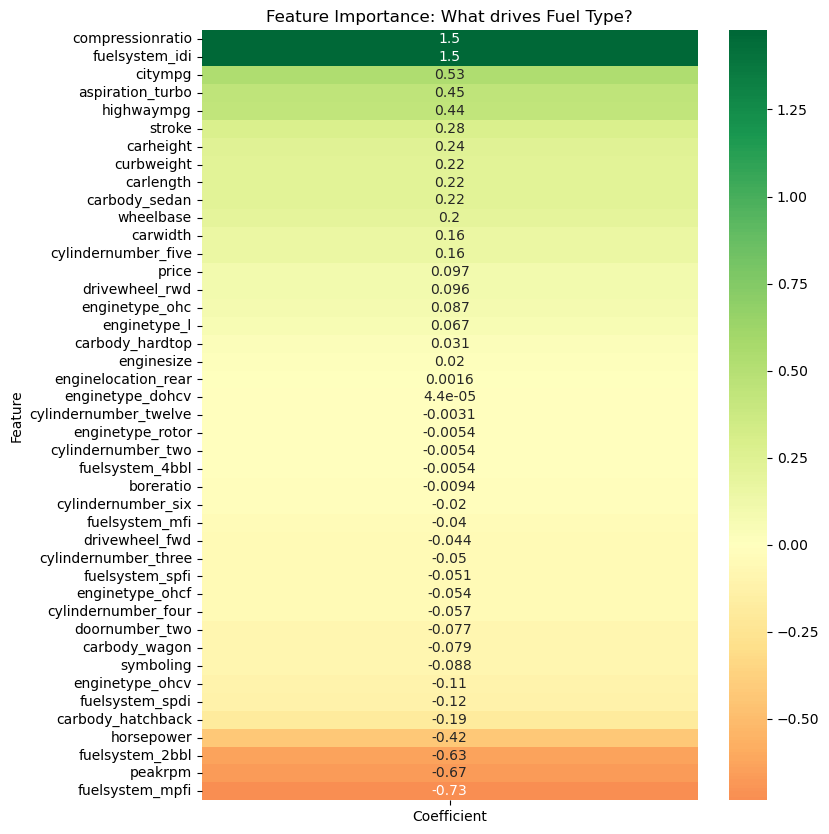

In [63]:
# 1. Prepare data (setting Feature as index so it appears as labels)
plt.figure(figsize=(8, 10))
df_heatmap = feature_importance.sort_values(by='Coefficient', ascending=False).set_index('Feature')

# 2. Plotting the heatmap
sns.heatmap(df_heatmap, annot=True, cmap='RdYlGn', center=0)

plt.title('Feature Importance: What drives Fuel Type?')
plt.show()

**Observation:-** 
- The heatmap shows that Compression Ratio is the strongest predictor for Diesel, while high Peak RPM and Horsepower are the main indicators of a Gas engine.
- This confirms that the model distinguishes fuel types based on high-pressure efficiency versus high-speed performance.